# Exploratory Data Analysis - Ames Housing Dataset

## Context
This notebook explores the [Ames Housing dataset](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques),
a Kaggle regression competition where the goal is to predict residential property sale prices (`SalePrice`)
based on 79 explanatory variables describing almost every aspect of homes in Ames, Iowa.

## Objectives
- Understand the distribution of variables and identify missing values
- Select the most informative features for modeling
- Define encoding, imputation, and outlier treatment strategies
- Feed decisions into `02_Preprocessing.ipynb`

## Table of Contents
1. [Import & Data Loading](#1-import-data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Missing Values Analysis](#3-missing-values-analysis)
4. [Categorical Variables Analysis](#4-categorical-variables-analysis)
5. [Target Variable Analysis - SalePrice](#5-target-variable-analysis)
6. [Correlation Analysis](#6-correlation-analysis)
7. [Key Features Analysis](#7-key-features-analysis)
8. [Outlier Detection](#8-outlier-detection)
9. [Multicollinearity Analysis](#9-multicollinearity-analysis)
10. [Temporal Analysis](#10-temporal-analysis)

## 1. Import & Data Loading <a id="1-import-data-loading"></a>

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

train = pd.read_csv("../data/raw/train.csv")
test  = pd.read_csv("../data/raw/test.csv")

print("Train :", train.shape)
print("Test  :", test.shape)
train.head()

Train : (1460, 81)
Test  : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Dataset Overview <a id="2-dataset-overview"></a>

In [85]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 3. Missing Values Analysis <a id="3-missing-values-analysis"></a>

In [86]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count" : missing,
    "Missing (%)" : missing_pct
})

print(f"{len(missing_df)} features have missing values out of {train.shape[1]} total\n")
print(missing_df.to_string())

19 features have missing values out of 81 total

              Missing Count  Missing (%)
PoolQC                 1453        99.52
MiscFeature            1406        96.30
Alley                  1369        93.77
Fence                  1179        80.75
MasVnrType              872        59.73
FireplaceQu             690        47.26
LotFrontage             259        17.74
GarageType               81         5.55
GarageYrBlt              81         5.55
GarageFinish             81         5.55
GarageQual               81         5.55
GarageCond               81         5.55
BsmtFinType2             38         2.60
BsmtExposure             38         2.60
BsmtFinType1             37         2.53
BsmtCond                 37         2.53
BsmtQual                 37         2.53
MasVnrArea                8         0.55
Electrical                1         0.07


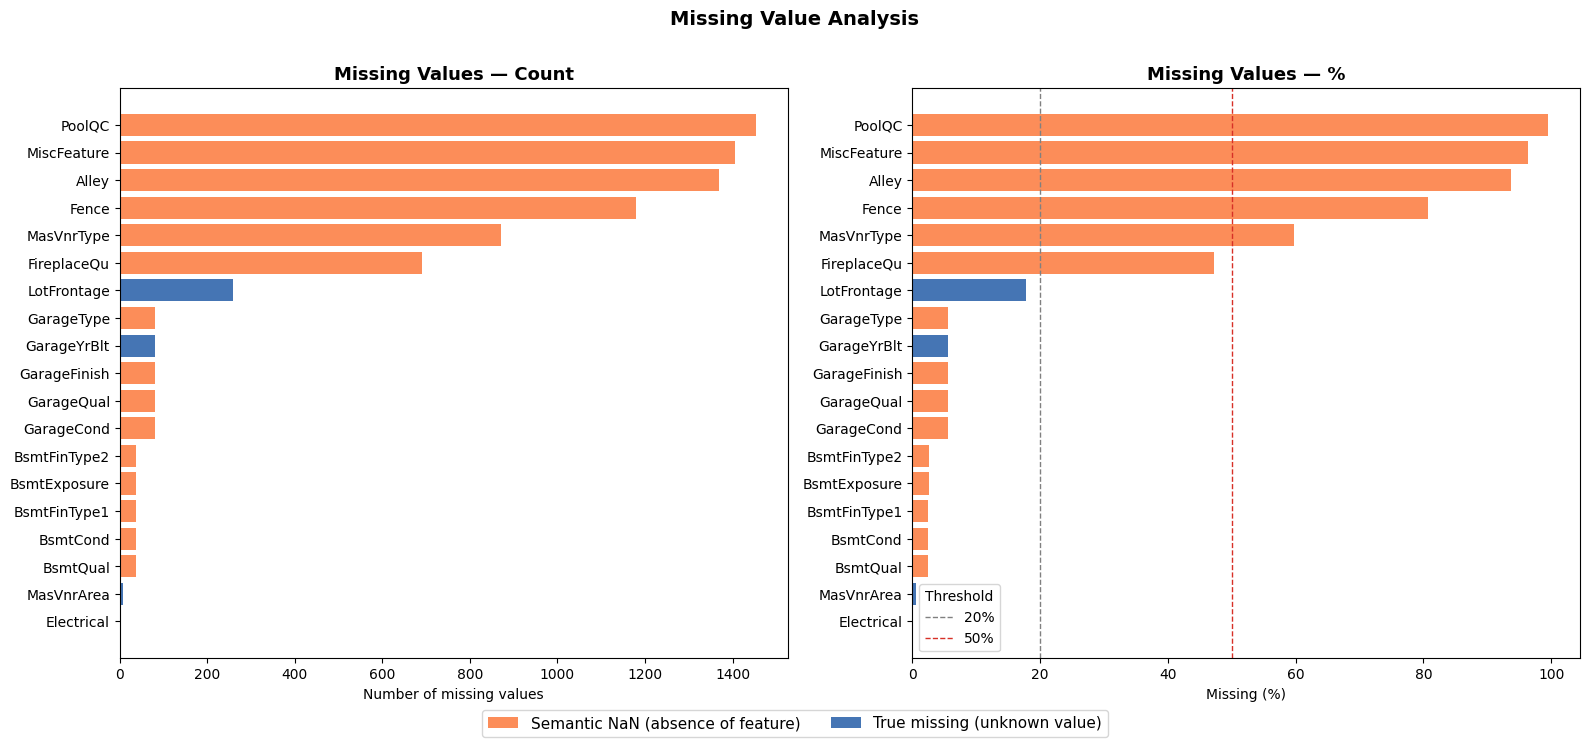

In [ ]:
semantic_feats = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'MasVnrType'
]

colors = ['#fc8d59' if feat in semantic_feats else '#4575b4'
          for feat in missing_df.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# absolute count
axes[0].barh(missing_df.index, missing_df["Missing Count"], color=colors)
axes[0].set_title("Missing Values - Count", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of missing values")
axes[0].invert_yaxis()

# percentage with threshold lines
axes[1].barh(missing_df.index, missing_df["Missing (%)"], color=colors)
axes[1].axvline(x=20, color="gray",   linestyle="--", linewidth=1, label="20%")
axes[1].axvline(x=50, color="#d73027", linestyle="--", linewidth=1, label="50%")
axes[1].set_title("Missing Values - %", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Missing (%)")
axes[1].invert_yaxis()
axes[1].legend(title="Threshold")

# Legend for color
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#fc8d59', label='Semantic NaN (absence of feature)'),
    Patch(facecolor='#4575b4', label='True missing (unknown value)')
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.04), fontsize=11)

plt.suptitle("Missing Value Analysis",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Key Takeaways - Missing Values Analysis

The dataset contains 19 features with missing values, but the vast majority of them
are **not genuine data gaps**. Cross-referencing with the data dictionary reveals two
fundamentally different types of missingness.

**Semantic NaN (16 features)** - The missing value explicitly encodes the absence of
a physical feature. `PoolQC` is missing for 99.5% of observations simply because
most houses have no pool. The same logic applies to `Alley`, `Fence`, `MiscFeature`,
and all basement, garage, and fireplace quality columns. These will be filled with
`'None'` for categorical features and `0` for their associated numerical counterparts.
Dropping or imputing these columns would destroy meaningful information.

**True missing (3 features)** - Only `LotFrontage`, `GarageYrBlt`, and `Electrical`
represent genuine unknown values requiring imputation. `LotFrontage` (18% missing)
will be imputed using the median grouped by `Neighborhood`, as houses within the
same area tend to share similar street configurations. `GarageYrBlt` will be filled
with `YearBuilt`, and `Electrical` with its mode.

This distinction - informed by the data dictionary rather than a blind missingness
rate threshold - prevents the common mistake of dropping high-NaN features that
actually carry strong predictive signal.

## 4. Categorical Variables Analysis <a id="4-categorical-variables-analysis"></a>

This section focuses on categorical features and their relationship with `SalePrice`.
Features were selected along two complementary axes:

**Domain knowledge** - In real estate, price is primarily driven by perceived quality,
location, and property type. This directly motivates the inclusion of:
- `KitchenQual`, `ExterQual`, `BsmtQual`, `GarageFinish` - condition ratings that
  buyers explicitly evaluate during visits
- `MSZoning`, `BldgType`, `HouseStyle` - structural and zoning attributes that
  define the property category and its market segment
- `Neighborhood` - location is one of the strongest price determinants in any
  real estate market, independent of the property's physical attributes
- `SaleCondition` - distinguishes arm's-length transactions from distressed sales
  (foreclosures, short sales), which systematically trade at a discount

**Preliminary correlation screening** - Features such as `Utilities`, `Street`,
and `Condition2` were excluded after confirming near-zero variance
(>99% of observations in a single category), making them uninformative regardless
of any domain rationale.

Two sub-analyses are conducted:
1. **Quality features** - ordinal variables with a natural ranking (Ex > Gd > TA > Fa)
2. **Structural & contextual features** - nominal variables analyzed by median price per category

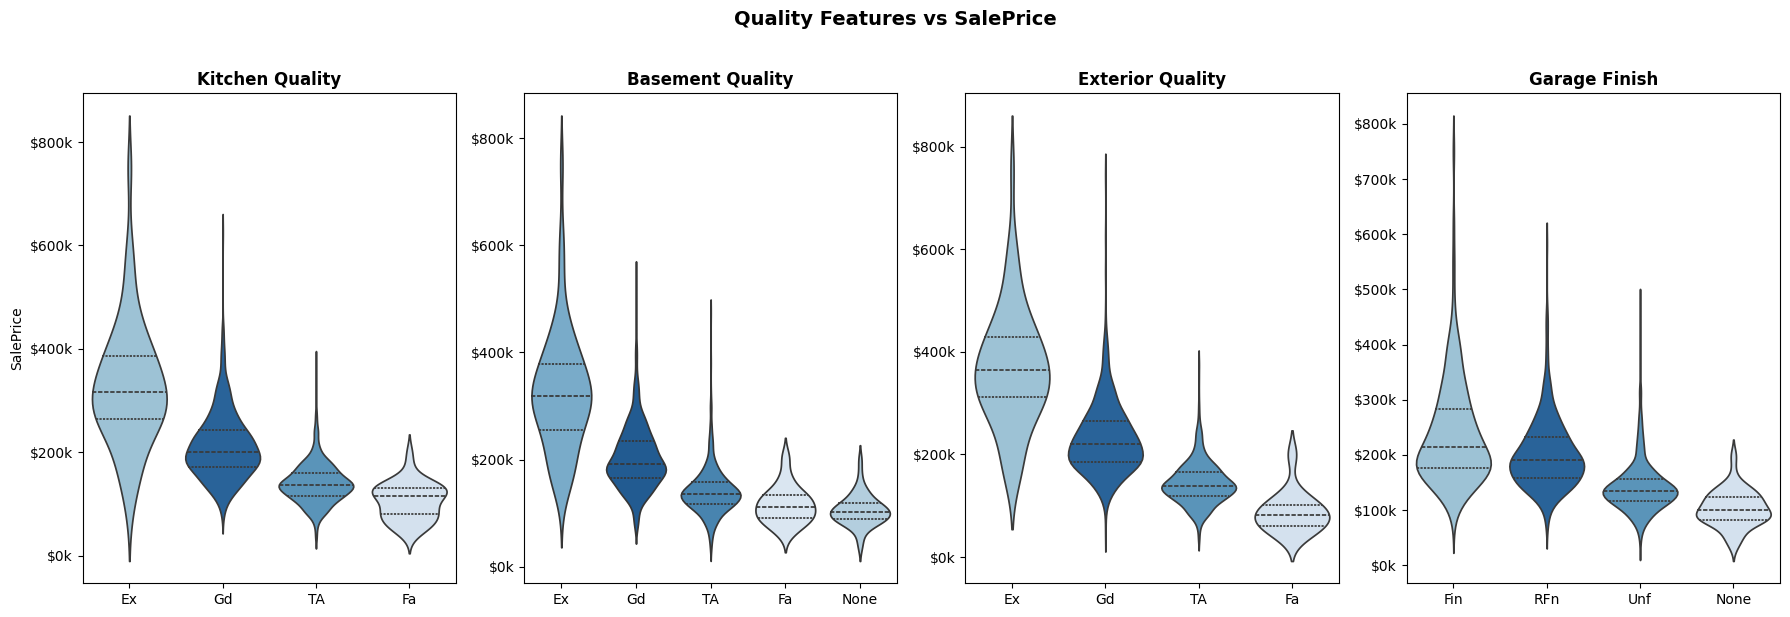

In [ ]:
quality_features = {
    'KitchenQual' : 'Kitchen Quality',
    'BsmtQual'    : 'Basement Quality',
    'ExterQual'   : 'Exterior Quality',
    'GarageFinish': 'Garage Finish',
}

quality_order = {
    'KitchenQual' : ['Ex', 'Gd', 'TA', 'Fa'],
    'BsmtQual'    : ['Ex', 'Gd', 'TA', 'Fa', 'None'],
    'ExterQual'   : ['Ex', 'Gd', 'TA', 'Fa'],
    'GarageFinish': ['Fin', 'RFn', 'Unf', 'None'],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (feat, title) in enumerate(quality_features.items()):
    plot_data = train.copy()
    plot_data[feat] = plot_data[feat].fillna('None')

    sns.violinplot(
        data=plot_data, x=feat, y='SalePrice',
        order=quality_order[feat],
        hue=feat, palette='Blues_r', legend=False,
        inner='quartile', ax=axes[i]
    )
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k')
    )
    if i > 0:
        axes[i].set_ylabel('')

plt.suptitle("Quality Features vs SalePrice",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

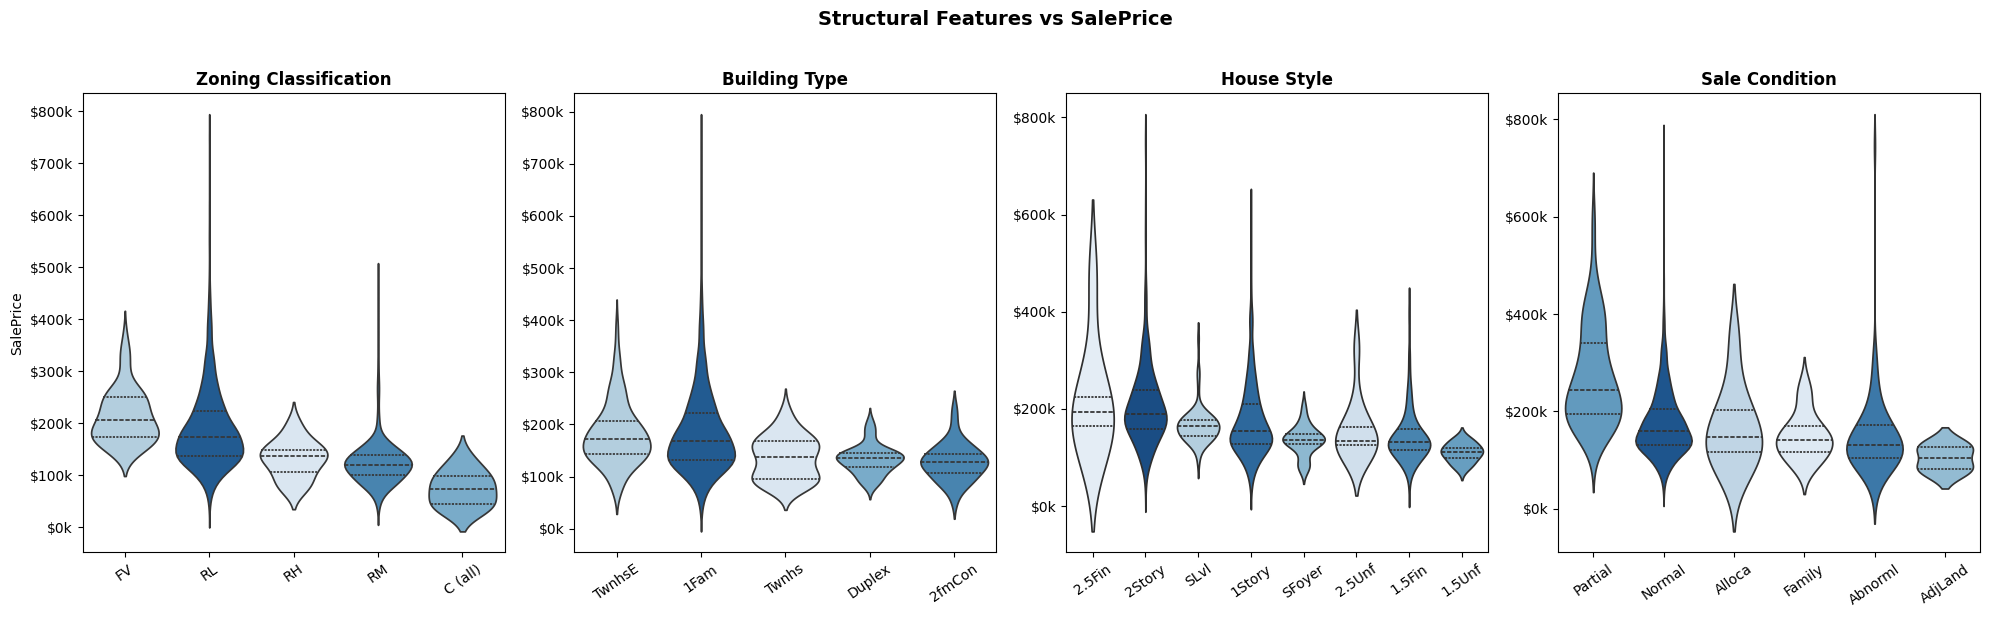

In [90]:
structural_features = {
    'MSZoning'     : 'Zoning Classification',
    'BldgType'     : 'Building Type',
    'HouseStyle'   : 'House Style',
    'SaleCondition': 'Sale Condition',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, (feat, title) in enumerate(structural_features.items()):
    plot_data = train.copy()
    plot_data[feat] = plot_data[feat].fillna('None')

    order = (plot_data.groupby(feat)['SalePrice']
                      .median()
                      .sort_values(ascending=False)
                      .index)

    sns.violinplot(
        data=plot_data, x=feat, y='SalePrice',
        order=order,
        hue=feat, palette='Blues_r', legend=False,
        inner='quartile', ax=axes[i]
    )
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k')
    )
    if i > 0:
        axes[i].set_ylabel('')

plt.suptitle("Structural Features vs SalePrice",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

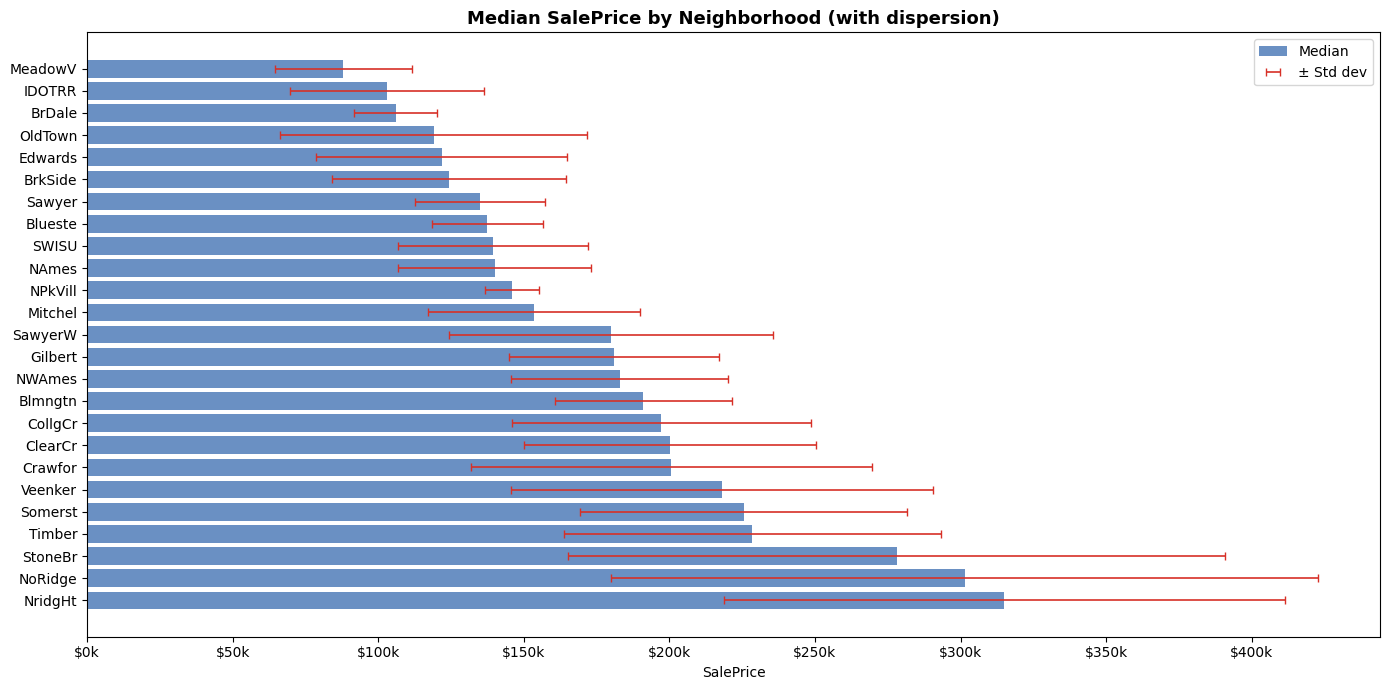

In [108]:
neighborhood_stats = (train.groupby('Neighborhood')['SalePrice']
                           .agg(['median', 'mean', 'std', 'count'])
                           .sort_values('median', ascending=False))
neighborhood_stats.columns = ['Median', 'Mean', 'Std', 'Count']

fig, ax = plt.subplots(figsize=(14, 7))

ax.barh(neighborhood_stats.index, neighborhood_stats['Median'],
        color='#4575b4', alpha=0.8, label='Median')

# Error bars showing dispersion
ax.errorbar(neighborhood_stats['Median'],
            neighborhood_stats.index,
            xerr=neighborhood_stats['Std'],
            fmt='none', color='#d73027', linewidth=1.2,
            capsize=3, label='± Std dev')

ax.set_title('Median SalePrice by Neighborhood (with dispersion)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('SalePrice')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k')
)
ax.legend()
plt.tight_layout()
plt.show()

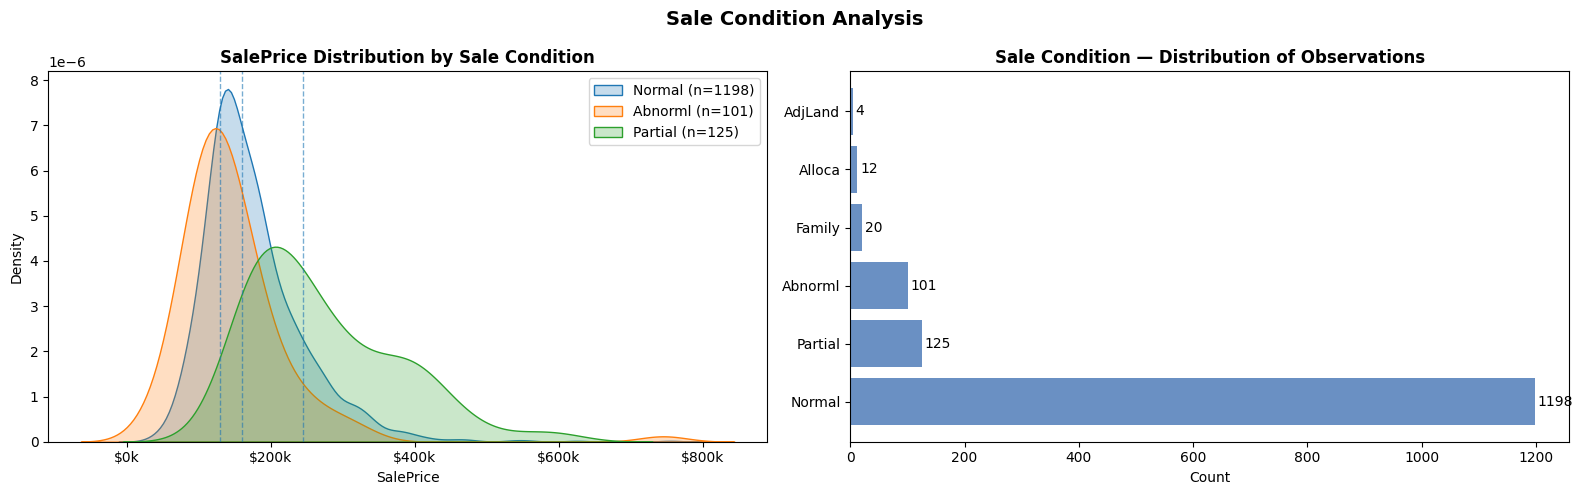

Normal   median: $  160,000 | mean: $  175,202 | n: 1198
Abnorml  median: $  130,000 | mean: $  146,527 | n: 101
Partial  median: $  244,600 | mean: $  272,292 | n: 125


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

conditions = {
    'Normal'  : train[train['SaleCondition'] == 'Normal']['SalePrice'],
    'Abnorml' : train[train['SaleCondition'] == 'Abnorml']['SalePrice'],
    'Partial' : train[train['SaleCondition'] == 'Partial']['SalePrice'],
}

for label, data in conditions.items():
    axes[0].axvline(data.median(), linestyle='--', linewidth=1, alpha=0.6)
    sns.kdeplot(data, ax=axes[0], label=f"{label} (n={len(data)})", fill=True, alpha=0.25)

axes[0].set_title('SalePrice Distribution by Sale Condition', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SalePrice')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

condition_counts = train['SaleCondition'].value_counts()
axes[1].barh(condition_counts.index, condition_counts.values, color='#4575b4', alpha=0.8)
axes[1].set_title('Sale Condition - Distribution of Observations', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(condition_counts.values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=10)

plt.suptitle('Sale Condition Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for label, data in conditions.items():
    print(f"{label:<8} median: ${data.median():>9,.0f} | mean: ${data.mean():>9,.0f} | n: {len(data)}")

In [110]:
features_to_test = {
    'KitchenQual'  : 'Kitchen Quality',
    'BsmtQual'     : 'Basement Quality',
    'ExterQual'    : 'Exterior Quality',
    'GarageFinish' : 'Garage Finish',
    'MSZoning'     : 'Zoning Classification',
    'BldgType'     : 'Building Type',
    'HouseStyle'   : 'House Style',
    'SaleCondition': 'Sale Condition',
}

print(f"{'Feature':<20} {'Title':<30} {'H-statistic':>12} {'p-value':>12} {'Significant':>12}")
print("-" * 90)

for feat, title in features_to_test.items():
    plot_data = train.copy()
    plot_data[feat] = plot_data[feat].fillna('None')

    groups = [
        group['SalePrice'].values
        for _, group in plot_data.groupby(feat)
        if len(group) >= 5  # exclude categories with too few observations
    ]

    h_stat, p_value = stats.kruskal(*groups)
    significant = "✓ Yes" if p_value < 0.05 else "✗ No"
    print(f"{feat:<20} {title:<30} {h_stat:>12.2f} {p_value:>12.2e} {significant:>12}")

Feature              Title                           H-statistic      p-value  Significant
------------------------------------------------------------------------------------------
KitchenQual          Kitchen Quality                      661.48    4.72e-143        ✓ Yes
BsmtQual             Basement Quality                     674.41    1.21e-144        ✓ Yes
ExterQual            Exterior Quality                     683.44    8.18e-148        ✓ Yes
GarageFinish         Garage Finish                        609.81    7.53e-132        ✓ Yes
MSZoning             Zoning Classification                270.07     3.08e-57        ✓ Yes
BldgType             Building Type                         69.80     2.50e-14        ✓ Yes
HouseStyle           House Style                          185.43     1.39e-36        ✓ Yes
SaleCondition        Sale Condition                       162.03     5.38e-34        ✓ Yes


### Statistical Validation - Kruskal-Wallis Test

A Kruskal-Wallis test was applied to each categorical feature analyzed in this
section to confirm that the price differences visible in the violin plots are
statistically significant and not due to sampling noise.

The Kruskal-Wallis test was preferred over one-way ANOVA for two reasons:
- `SalePrice` is right-skewed and does not meet the normality assumption of ANOVA
- It is robust to unequal group sizes, which is the case here
  (e.g. `SaleCondition` has dominant `Normal` vs sparse `Partial`)

All features analyzed return p-values well below 0.05, confirming that the
observed price differences across categories are statistically significant.
The visual patterns from the violin plots are therefore reliable signals,
not visual artifacts.

### Key Takeaways - Categorical Variables Analysis

**Quality features** (`KitchenQual`, `ExterQual`, `BsmtQual`, `GarageFinish`) show
a consistent and monotonic relationship with `SalePrice`. The price gap between the
`Ex` and `Fa` categories reaches nearly $200k in median value, making these features
among the strongest predictors in the dataset. Their ordinal nature (Ex > Gd > TA > Fa)
justifies an **ordinal encoding** over one-hot encoding during preprocessing.

**Structural features** (`MSZoning`, `BldgType`, `HouseStyle`) show more modest
and irregular price differences. `1Fam` dwellings cover the entire price spectrum
while multi-unit types cluster in lower ranges. These features will be treated with
**one-hot encoding** given their lack of natural ordering.

**Sale Condition** reveals three distinct sale populations. Normal sales form the
reference distribution. Abnormal sales (foreclosures, short sales) are concentrated
in lower price ranges with a wider spread. Partial sales - homes sold before
completion - are shifted toward higher values and narrower distributions, reflecting
new construction premiums. A dedicated binary feature `is_new_construction` will
be created during feature engineering to isolate this effect.

**Encoding strategy summary:**

| Feature type        | Examples                              | Strategy         |
|---------------------|---------------------------------------|------------------|
| Ordinal quality     | KitchenQual, ExterQual, BsmtQual      | Ordinal encoding |
| Nominal structural  | BldgType, MSZoning, HouseStyle        | One-hot encoding |
| Nominal with NaN    | GarageType, Fence, Alley              | Fill None + OHE  |
| Sale condition flag | SaleCondition == Partial              | Binary flag      |

## 5. Target Variable Analysis - SalePrice <a id="5-target-variable-analysis"></a>

In [93]:
desc = train['SalePrice'].describe()
skewness = train['SalePrice'].skew()
kurtosis = train['SalePrice'].kurt()

print(desc.apply(lambda x: f"${x:,.0f}" if x > 1000 else f"{x:.2f}"))
print(f"\nSkewness : {skewness:.4f}")
print(f"Kurtosis : {kurtosis:.4f}")

count      $1,460
mean     $180,921
std       $79,443
min       $34,900
25%      $129,975
50%      $163,000
75%      $214,000
max      $755,000
Name: SalePrice, dtype: str

Skewness : 1.8829
Kurtosis : 6.5363


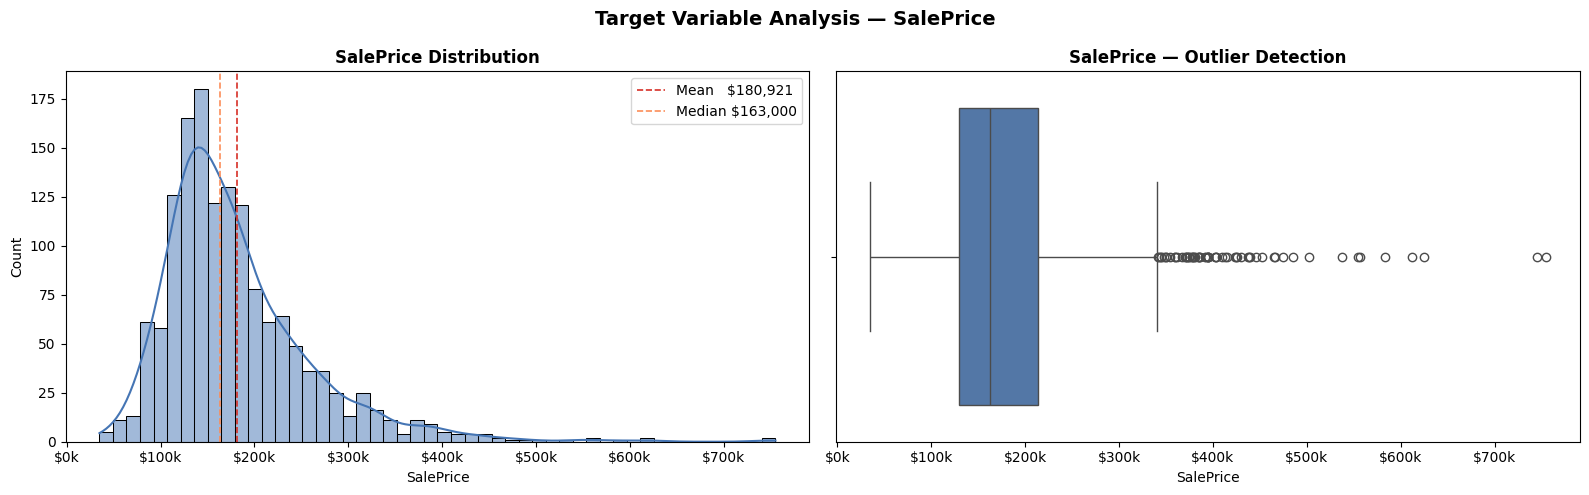

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(train['SalePrice'], bins=50, kde=True, ax=axes[0], color='#4575b4')
axes[0].axvline(train['SalePrice'].mean(),   color='#d73027', linestyle='--',
                linewidth=1.2, label=f"Mean   ${train['SalePrice'].mean():,.0f}")
axes[0].axvline(train['SalePrice'].median(), color='#fc8d59', linestyle='--',
                linewidth=1.2, label=f"Median ${train['SalePrice'].median():,.0f}")
axes[0].set_title('SalePrice Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('SalePrice')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

sns.boxplot(x=train['SalePrice'], ax=axes[1], color='#4575b4')
axes[1].set_title('SalePrice - Outlier Detection', fontsize=12, fontweight='bold')
axes[1].set_xlabel('SalePrice')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('Target Variable Analysis - SalePrice',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations

- The distribution is **right-skewed** (skewness ≈ 1.88), with a long tail toward
  high-value properties pulling the mean above the median by roughly $15k.
- The boxplot confirms the presence of high-price outliers beyond $400k that will
  exert undue influence on linear models.
- A `log1p` transformation will be applied to `SalePrice` in the preprocessing
  stage to normalize the distribution and stabilize variance.

## 6. Correlation Analysis <a id="6-correlation-analysis"></a>

To identify which numerical features are most linearly associated with `SalePrice`,
we compute Pearson correlations across all numerical variables. This analysis directly
informs the selection of features to investigate in depth in the next section.

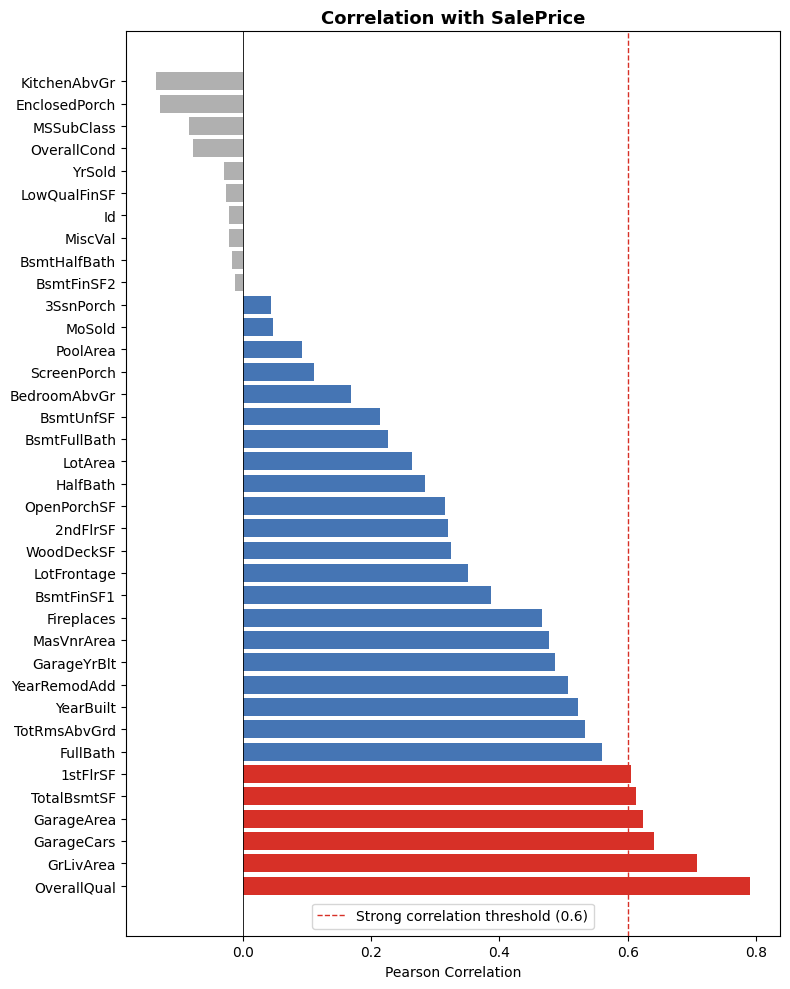

Features with correlation ≥ 0.6 with SalePrice (6):
  OverallQual          : 0.7910
  GrLivArea            : 0.7086
  GarageCars           : 0.6404
  GarageArea           : 0.6234
  TotalBsmtSF          : 0.6136
  1stFlrSF             : 0.6059


In [95]:
corr = train.select_dtypes(include=np.number).corr()['SalePrice']
corr = corr.drop('SalePrice').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))

colors = ['#d73027' if v >= 0.6 else '#4575b4' if v >= 0 else '#b0b0b0'
          for v in corr.values]

ax.barh(corr.index, corr.values, color=colors)
ax.axvline(x=0.6, color='#d73027', linestyle='--', linewidth=1,
           label='Strong correlation threshold (0.6)')
ax.axvline(x=0,   color='black',   linestyle='-',  linewidth=0.6)
ax.set_title('Correlation with SalePrice', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.legend()
plt.tight_layout()
plt.show()

top_features = corr[corr >= 0.6].index.tolist()
print(f"Features with correlation ≥ 0.6 with SalePrice ({len(top_features)}):")
for feat in top_features:
    print(f"  {feat:<20} : {corr[feat]:.4f}")

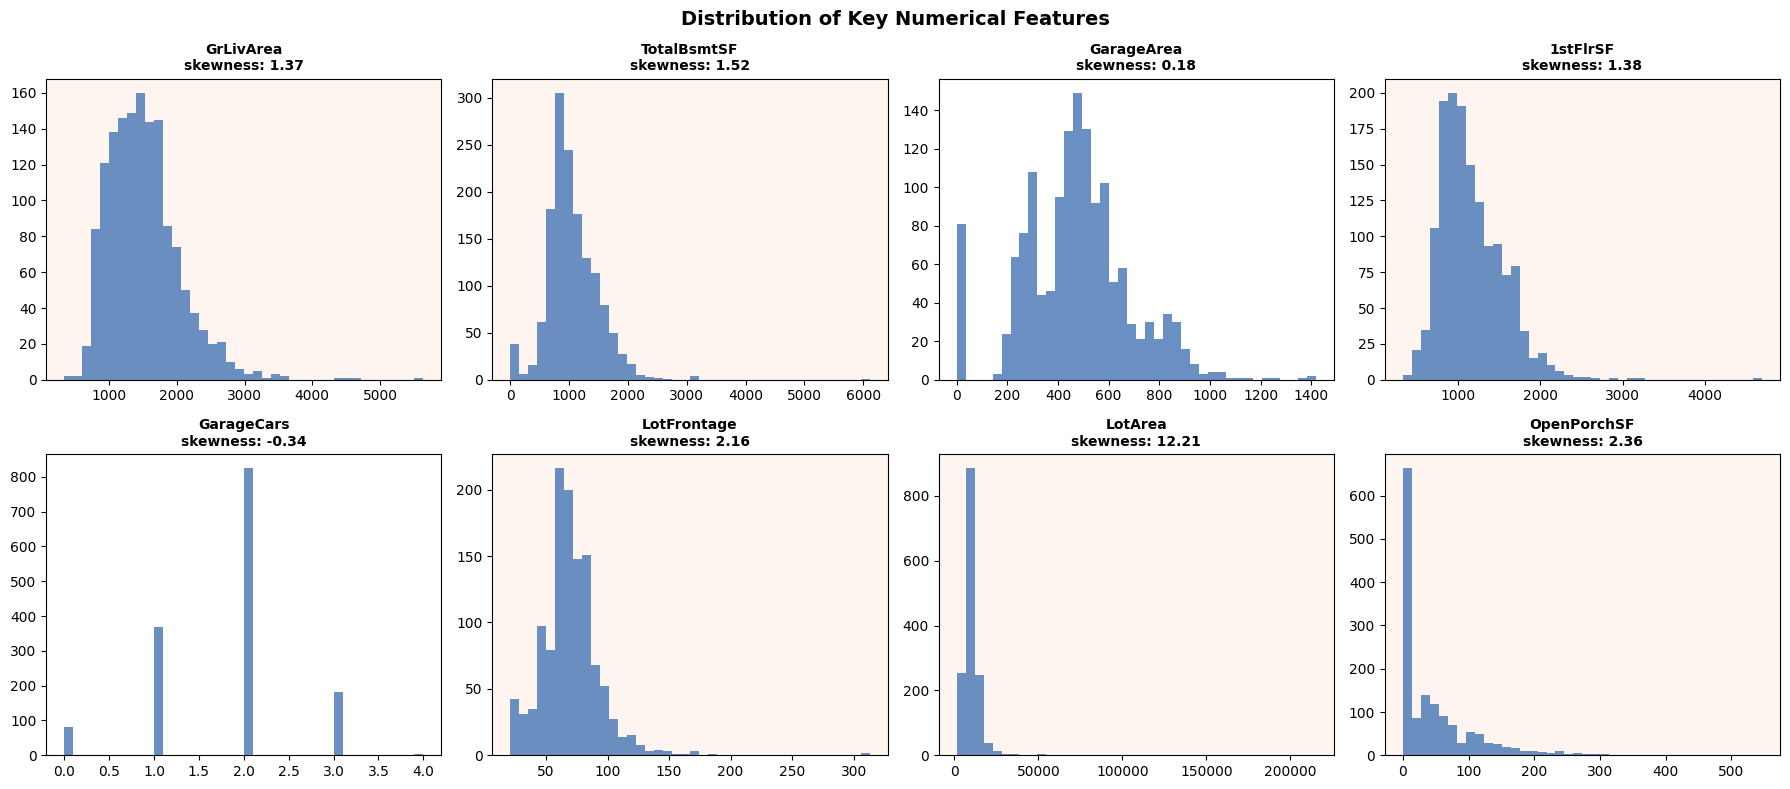

Features nécessitant une transformation log :
  GrLivArea            skewness = 1.37
  TotalBsmtSF          skewness = 1.52
  1stFlrSF             skewness = 1.38
  LotFrontage          skewness = 2.16
  LotArea              skewness = 12.21
  OpenPorchSF          skewness = 2.36


In [115]:
numerical_features = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 
                       '1stFlrSF', 'GarageCars', 'LotFrontage',
                       'LotArea', 'OpenPorchSF']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(numerical_features):
    skew_val = train[feat].skew()
    axes[i].hist(train[feat].dropna(), bins=40, color='#4575b4', alpha=0.8)
    axes[i].set_title(f'{feat}\nskewness: {skew_val:.2f}', 
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    if skew_val > 0.75:
        axes[i].set_facecolor('#fff5f0')  # fond légèrement orangé si très skewed

plt.suptitle('Distribution of Key Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé des skewness
print("Features nécessitant une transformation log :")
for feat in numerical_features:
    s = train[feat].skew()
    if abs(s) > 0.75:
        print(f"  {feat:<20} skewness = {s:.2f}")

### Key Takeaways - Correlation Analysis

Six features show a strong linear correlation with `SalePrice` (r ≥ 0.6):
`OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62),
`TotalBsmtSF` (0.61), and `1stFlrSF` (0.61).

Several observations are worth noting:

- `OverallQual` is the single strongest predictor, confirming what the categorical
  analysis already suggested - perceived quality drives price more than any
  physical measurement.
- `GarageCars` and `GarageArea` are highly correlated with each other (multicollinearity)
  and both strongly correlated with `SalePrice`. Only one may be needed in the final model.
- `TotalBsmtSF` and `1stFlrSF` are also redundant for the same reason.
- `YrSold` and `OverallCond` show near-zero correlation - they carry little linear
  signal and may be dropped or transformed.

**Note on Pearson limitations** - These correlations are computed on raw, untransformed
values. Given the right-skewed distributions of several features (`GrLivArea`,
`TotalBsmtSF`, `SalePrice`), Pearson coefficients likely underestimate the true
association strength. Correlations will be re-evaluated after log-transformation
in `02_Preprocessing.ipynb`.

## 7. Key Features Analysis <a id="7-key-features-analysis"></a>

The following features were selected based on the correlation analysis conducted
in section 6, retaining only variables with a Pearson correlation ≥ 0.6 with
`SalePrice`: `GrLivArea`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`, `GarageCars`,
and `OverallQual`.

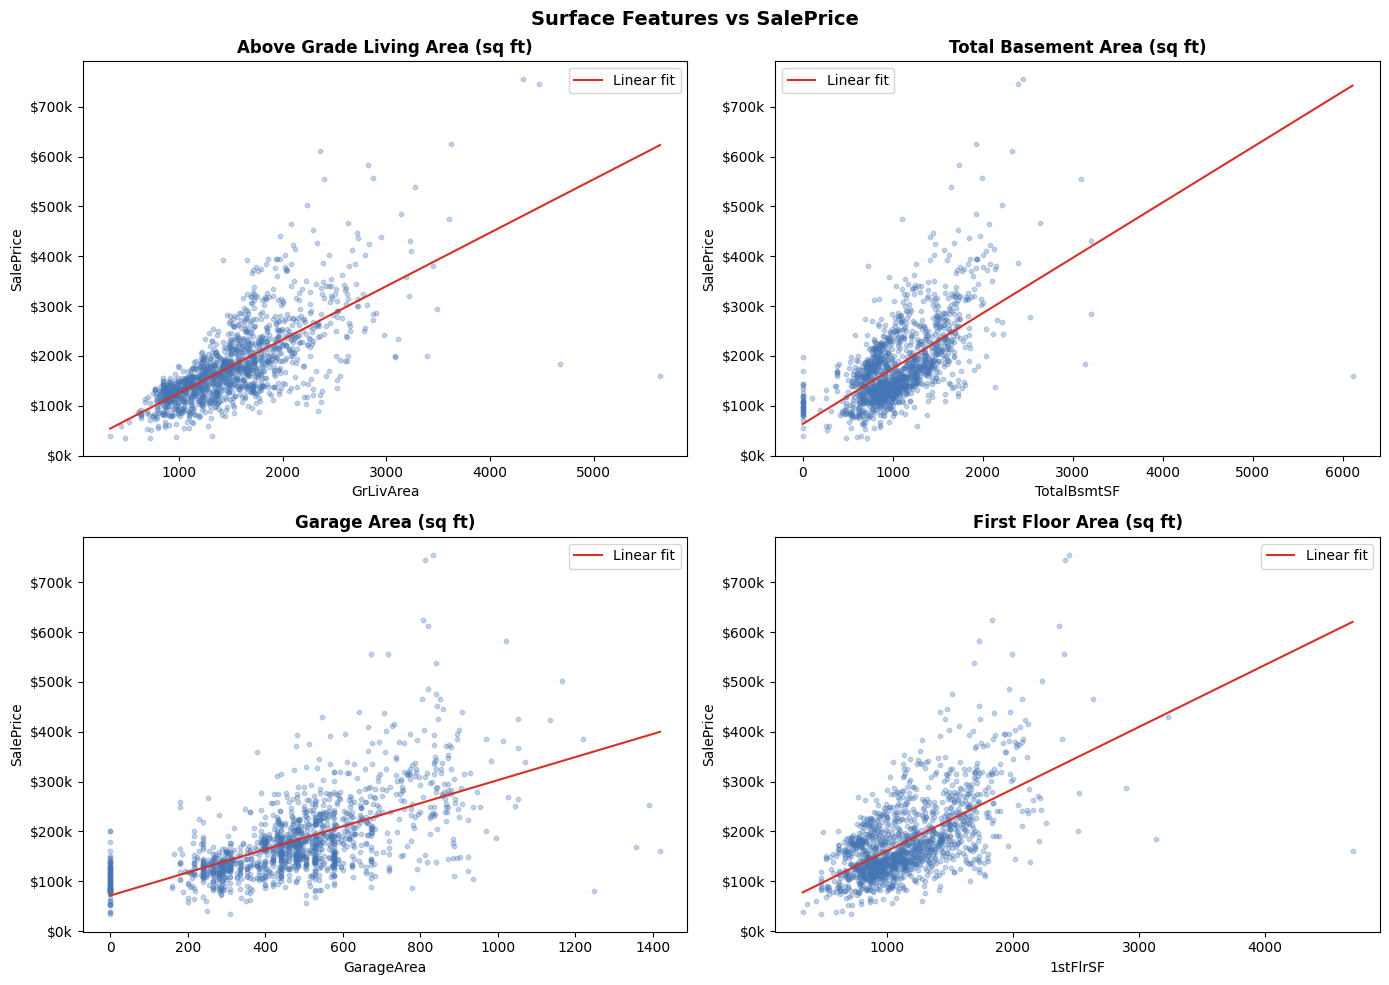

In [96]:
surface_features = {
    'GrLivArea'   : 'Above Grade Living Area (sq ft)',
    'TotalBsmtSF' : 'Total Basement Area (sq ft)',
    'GarageArea'  : 'Garage Area (sq ft)',
    '1stFlrSF'    : 'First Floor Area (sq ft)',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feat, title) in enumerate(surface_features.items()):
    axes[i].scatter(train[feat], train['SalePrice'],
                    alpha=0.3, s=10, color='#4575b4')

    # Regression line
    m, b = np.polyfit(train[feat].fillna(0), train['SalePrice'], 1)
    x_line = np.linspace(train[feat].min(), train[feat].max(), 100)
    axes[i].plot(x_line, m * x_line + b,
                 color='#d73027', linewidth=1.5, label='Linear fit')

    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[i].legend()

plt.suptitle('Surface Features vs SalePrice',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

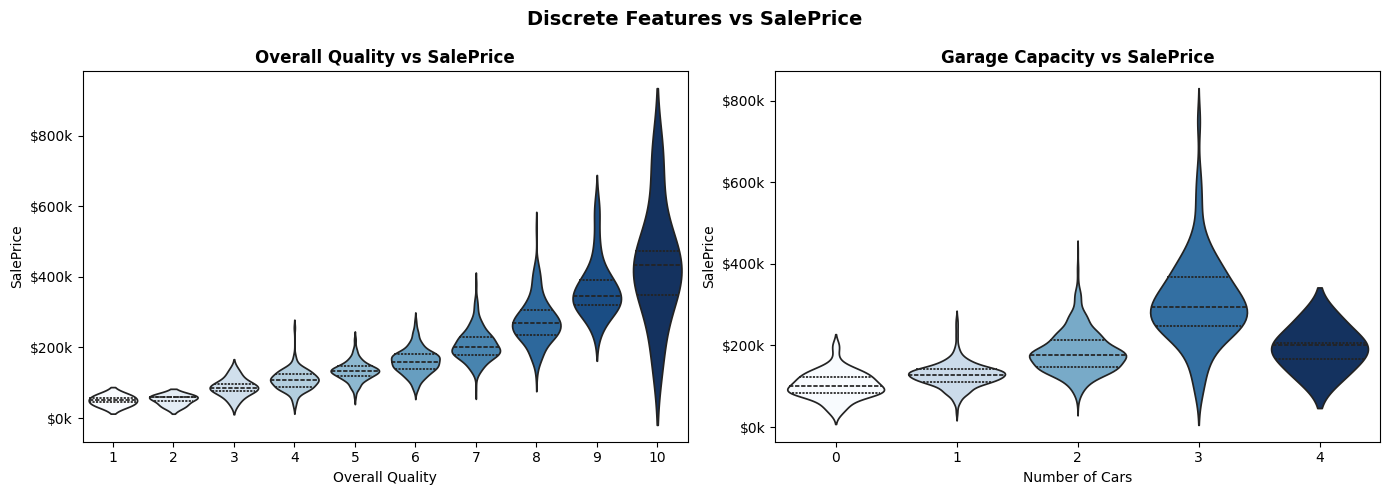

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OverallQual
sns.violinplot(data=train, x='OverallQual', y='SalePrice',
               hue='OverallQual', palette='Blues', legend=False,
               inner='quartile', ax=axes[0])
axes[0].set_title('Overall Quality vs SalePrice',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Overall Quality')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# GarageCars
sns.violinplot(data=train, x='GarageCars', y='SalePrice',
               hue='GarageCars', palette='Blues', legend=False,
               inner='quartile', ax=axes[1])
axes[1].set_title('Garage Capacity vs SalePrice',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Cars')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('Discrete Features vs SalePrice',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Takeaways - Key Features Analysis

**Surface features** all show a positive linear relationship with `SalePrice`,
but with varying degrees of dispersion. `GrLivArea` is the cleanest predictor -
the relationship is nearly linear across the full range. `TotalBsmtSF` and
`GarageArea` show more scatter, suggesting these features interact with other
variables (quality, neighborhood) to determine the final price. The two outliers
identified earlier (large `GrLivArea`, low price) are clearly visible and confirm
the need for removal before modeling.

**Overall Quality** shows the strongest and most regular pattern - each quality
step produces a consistent median price increase with progressively wider
distributions at higher grades, reflecting greater heterogeneity among premium
properties.

**Garage capacity** follows a similar ordinal pattern up to 3 cars. The 4-car
category shows an unexpectedly wide distribution likely due to its small sample
size, and should be treated with caution.

**Multicollinearity note**: `GarageArea` and `GarageCars` both describe the same
physical feature from different angles. `TotalBsmtSF` and `1stFlrSF` are similarly
redundant. Only one from each pair will be retained in the final model, a decision
to be made during feature selection.

## 8. Outlier Detection <a id="8-outlier-detection"></a>

Outliers are identified on the key features selected in section 7. We use two
complementary approaches:

- **IQR method** - flags observations that fall beyond 1.5× the interquartile
  range. Robust and distribution-free, but aggressive on skewed features.
- **Visual inspection** - scatter plots against `SalePrice` to distinguish
  genuine outliers from natural high-value properties.

In [98]:
key_features = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF', 'SalePrice']

def iqr_outliers(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask  = (df[col] < lower) | (df[col] > upper)
    return mask, lower, upper

print(f"{'Feature':<15} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>8}")
print("-" * 55)

outlier_masks = {}
for feat in key_features:
    mask, lower, upper = iqr_outliers(train, feat)
    outlier_masks[feat] = mask
    print(f"{feat:<15} {lower:>10.0f} {upper:>10.0f} "
          f"{mask.sum():>10} {mask.sum()/len(train)*100:>7.1f}%")

Feature              Lower      Upper   Outliers        %
-------------------------------------------------------
GrLivArea              159       2748         31     2.1%
TotalBsmtSF             42       2052         61     4.2%
GarageArea             -28        938         21     1.4%
1stFlrSF               118       2155         20     1.4%
SalePrice             3938     340038         61     4.2%


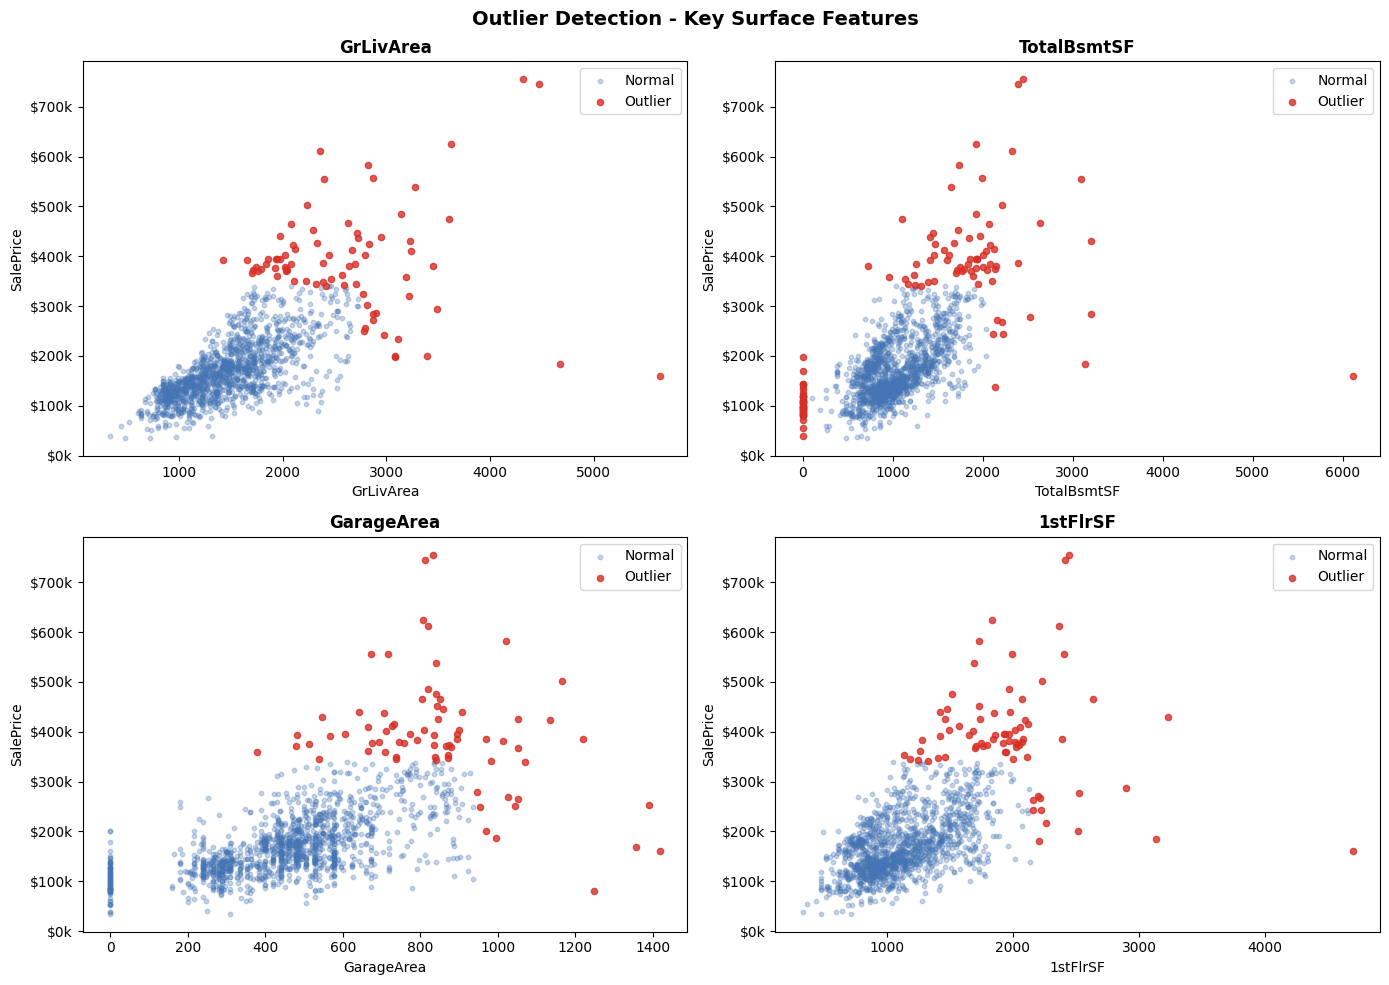

In [119]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

surface_features = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF']

for i, feat in enumerate(surface_features):
    combined_mask = outlier_masks[feat] | outlier_masks['SalePrice']
    normal  = train[~combined_mask]
    outlier = train[combined_mask]

    axes[i].scatter(normal[feat],  normal['SalePrice'],
                    alpha=0.3, s=10, color='#4575b4', label='Normal')
    axes[i].scatter(outlier[feat], outlier['SalePrice'],
                    alpha=0.8, s=20, color='#d73027', label='Outlier')

    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[i].legend()

plt.suptitle('Outlier Detection - Key Surface Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [118]:
# Large houses sold at unexpectedly low prices
suspicious = train[
    (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)
][['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'OverallQual',
   'Neighborhood', 'SaleCondition', 'SalePrice']]

print("Suspicious observations - large area, low price:")
print(suspicious.to_string())
print()

# High price outliers
high_price = train[train['SalePrice'] > train['SalePrice'].quantile(0.999)]
print(f"Extreme high-price properties (top 0.1%) : {len(high_price)}")
print(high_price[['GrLivArea', 'OverallQual', 'Neighborhood',
                   'SaleCondition', 'SalePrice']].to_string())

Suspicious observations - large area, low price:
      GrLivArea  TotalBsmtSF  GarageArea  OverallQual Neighborhood SaleCondition  SalePrice
523        4676         3138         884           10      Edwards       Partial     184750
1298       5642         6110        1418           10      Edwards       Partial     160000

Extreme high-price properties (top 0.1%) : 2
      GrLivArea  OverallQual Neighborhood SaleCondition  SalePrice
691        4316           10      NoRidge        Normal     755000
1182       4476           10      NoRidge       Abnorml     745000


### Key Takeaways - Outlier Detection

The IQR method flags a modest proportion of observations across key features -
between 1.4% (`GarageArea`, `1stFlrSF`) and 4.2% (`TotalBsmtSF`, `SalePrice`).
These rates are low enough that most flagged points are genuine high-value
properties rather than data errors.

Three categories of outliers emerge from the analysis:

**To remove** - Two observations combine `GrLivArea > 4,000 sq ft` with a
`SalePrice` below $300k (index 523 and 1298). These directly contradict the
linear trend established across all surface features and will distort linear
model coefficients. They are the only outliers where removal is clearly justified.
Removal rule applied in `02_Preprocessing.ipynb`:
```python
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300_000)].index)
```

**To retain** - The 61 high-price observations flagged by the IQR method on
`SalePrice` (above ~$340k) are consistent with the data. They correspond to
large, high-quality properties in premium neighborhoods and represent a real
segment of the market. Removing them would bias the model toward median properties.

**To monitor** - The outliers on `TotalBsmtSF` include houses with no basement
(value = 0), which are semantic NaN cases already handled in section 3, and a
small number of genuinely large basements that will be reviewed during feature
engineering.

## 9. Multicollinearity Analysis <a id="9-multicollinearity-analysis"></a>

Multicollinearity occurs when two or more features are strongly correlated with
each other, not just with the target. This is problematic for linear models as it
inflates coefficient variance and makes interpretation unreliable.

We examine multicollinearity across all numerical features using a correlation
heatmap, then isolate the most redundant pairs among our key features.

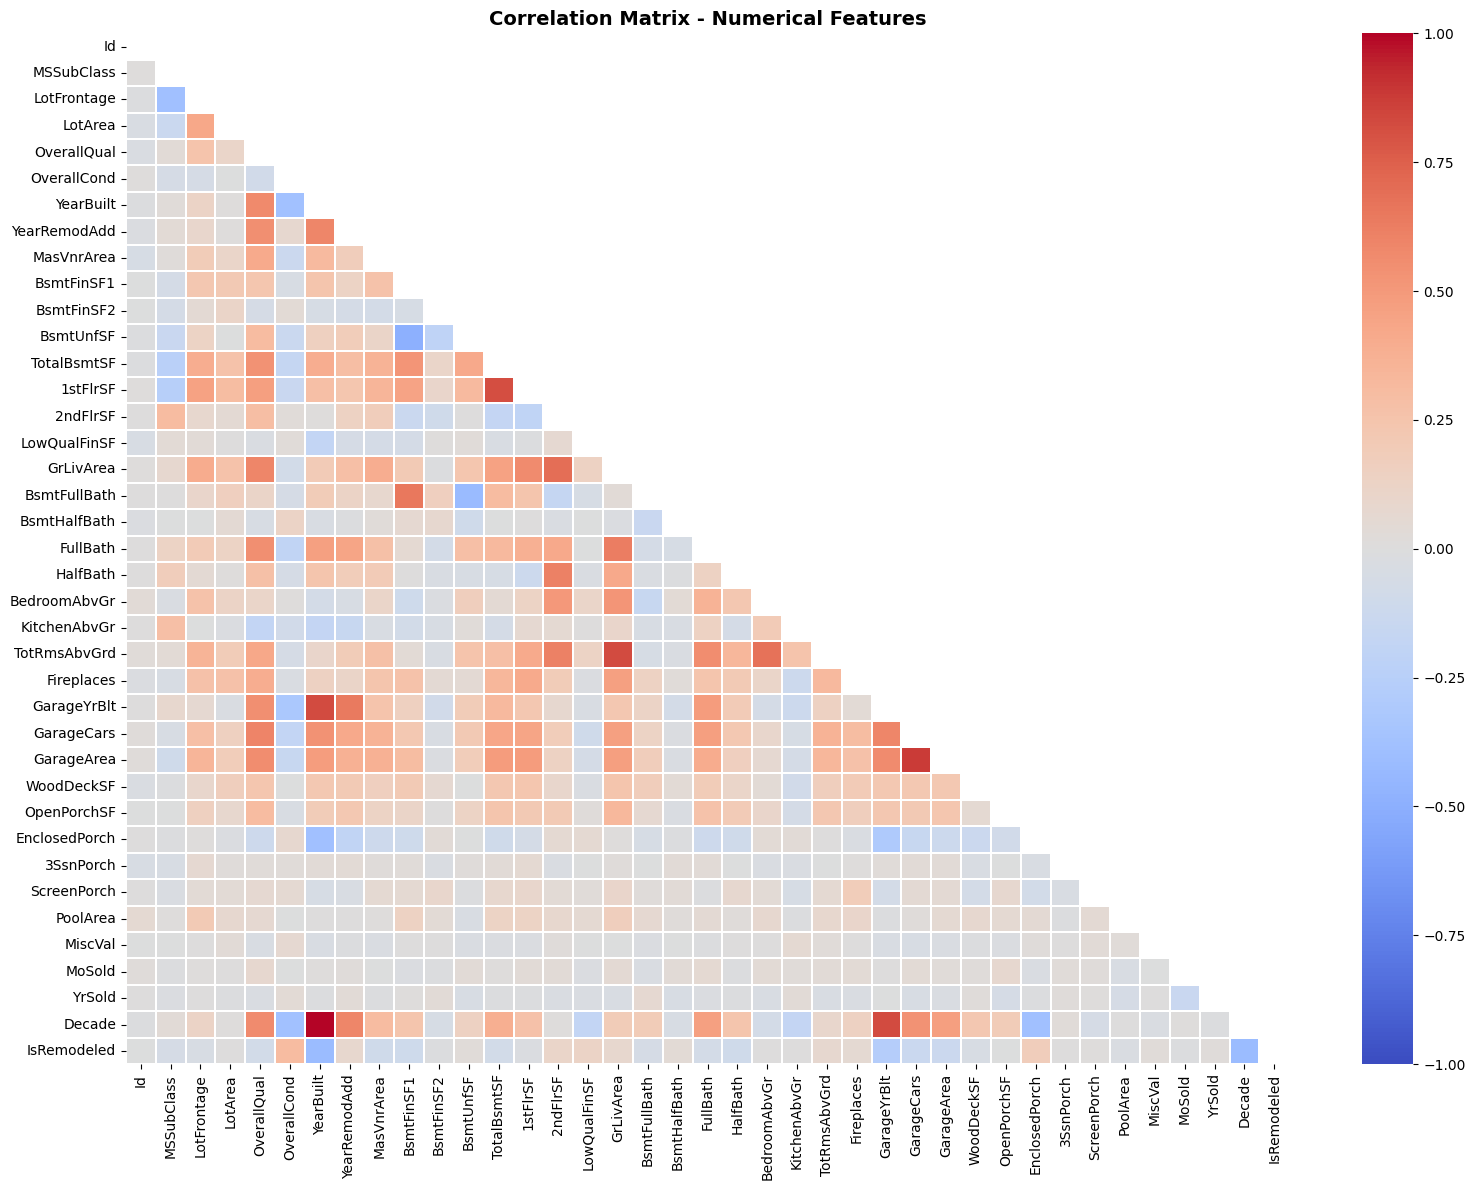

In [121]:
num_cols     = train.select_dtypes(include=np.number).columns.drop('SalePrice')
corr_matrix  = train[num_cols].corr()
mask         = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix - Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [102]:
corr_pairs = (corr_matrix.where(~mask)
                         .stack()
                         .reset_index())
corr_pairs.columns = ['Var1', 'Var2', 'Correlation']
corr_pairs['Correlation'] = corr_pairs['Correlation'].abs()
corr_pairs = (corr_pairs[corr_pairs['Var1'] != corr_pairs['Var2']]
                        .sort_values('Correlation', ascending=False))

print("Top 15 most correlated feature pairs:\n")
print(f"{'Var1':<20} {'Var2':<20} {'|Correlation|':>15}")
print("-" * 57)
for _, row in corr_pairs.head(15).iterrows():
    print(f"{row['Var1']:<20} {row['Var2']:<20} {row['Correlation']:>15.4f}")

Top 15 most correlated feature pairs:

Var1                 Var2                   |Correlation|
---------------------------------------------------------
GarageArea           GarageCars                    0.8825
GarageYrBlt          YearBuilt                     0.8257
TotRmsAbvGrd         GrLivArea                     0.8255
1stFlrSF             TotalBsmtSF                   0.8195
GrLivArea            2ndFlrSF                      0.6875
TotRmsAbvGrd         BedroomAbvGr                  0.6766
BsmtFullBath         BsmtFinSF1                    0.6492
GarageYrBlt          YearRemodAdd                  0.6423
FullBath             GrLivArea                     0.6300
TotRmsAbvGrd         2ndFlrSF                      0.6164
HalfBath             2ndFlrSF                      0.6097
GarageCars           OverallQual                   0.6007
GrLivArea            OverallQual                   0.5930
YearRemodAdd         YearBuilt                     0.5929
GarageCars           GarageYrBlt 

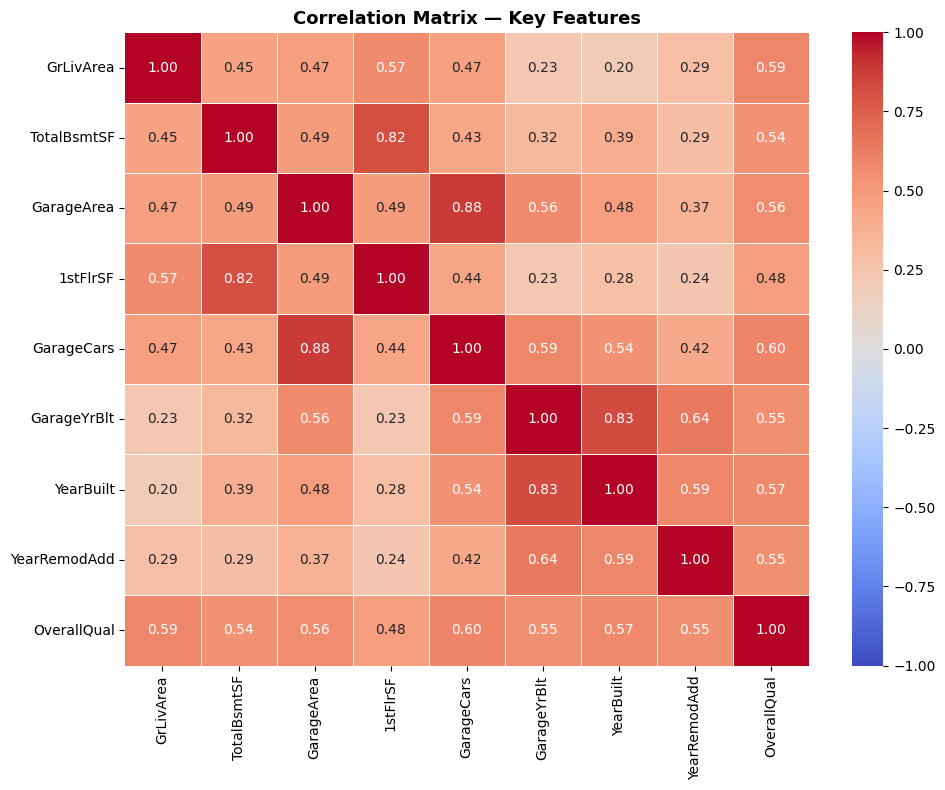

In [ ]:
key_features = ['GrLivArea', 'TotalBsmtSF', 'GarageArea',
                '1stFlrSF', 'GarageCars', 'GarageYrBlt',
                'YearBuilt', 'YearRemodAdd', 'OverallQual']
key_corr = train[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(key_corr, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix - Key Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Takeaways - Multicollinearity Analysis

The correlation matrix reveals three distinct clusters of intercorrelated features.

**Garage cluster** - `GarageArea` and `GarageCars` show the strongest redundancy
in the dataset (r = 0.88). Both measure garage size from different angles -
capacity in cars vs. square footage. `GarageYrBlt` is also moderately correlated
with both (0.56 and 0.59), as garages tend to be built around the same time as
the house. Only `GarageCars` will be retained as it is more interpretable.

**Surface cluster** - `TotalBsmtSF` and `1stFlrSF` are strongly correlated
(r = 0.82), confirming that the first floor footprint closely mirrors the
basement footprint in most properties. `GrLivArea` is more independent from
this pair (0.45 and 0.57) and will be preferred as the primary surface predictor.

**Time cluster** - `YearBuilt`, `GarageYrBlt`, and `YearRemodAdd` form a
moderately correlated group (0.59 to 0.83). The strongest link is between
`YearBuilt` and `GarageYrBlt` (r = 0.83), consistent with the observation
from section 3 that garage construction year can be imputed from build year.
A single engineered feature `HouseAge` derived from `YearBuilt` may replace
this entire cluster during feature engineering.

**OverallQual** remains the most independent feature across all pairs (max
correlation 0.60 with `GarageCars`), confirming its unique predictive value
already established in the correlation analysis.

*Feature selection and redundancy removal: see* `02_Preprocessing.ipynb`

## 10. Temporal Analysis <a id="10-temporal-analysis"></a>

### 10.1 House Age vs SalePrice

Newer houses are generally expected to command higher prices, but the relationship
may not be linear - a well-maintained older property can outperform a poorly built
recent one. We explore how `YearBuilt` relates to `SalePrice`, and whether
`YearRemodAdd` (remodel date) attenuates the age effect.

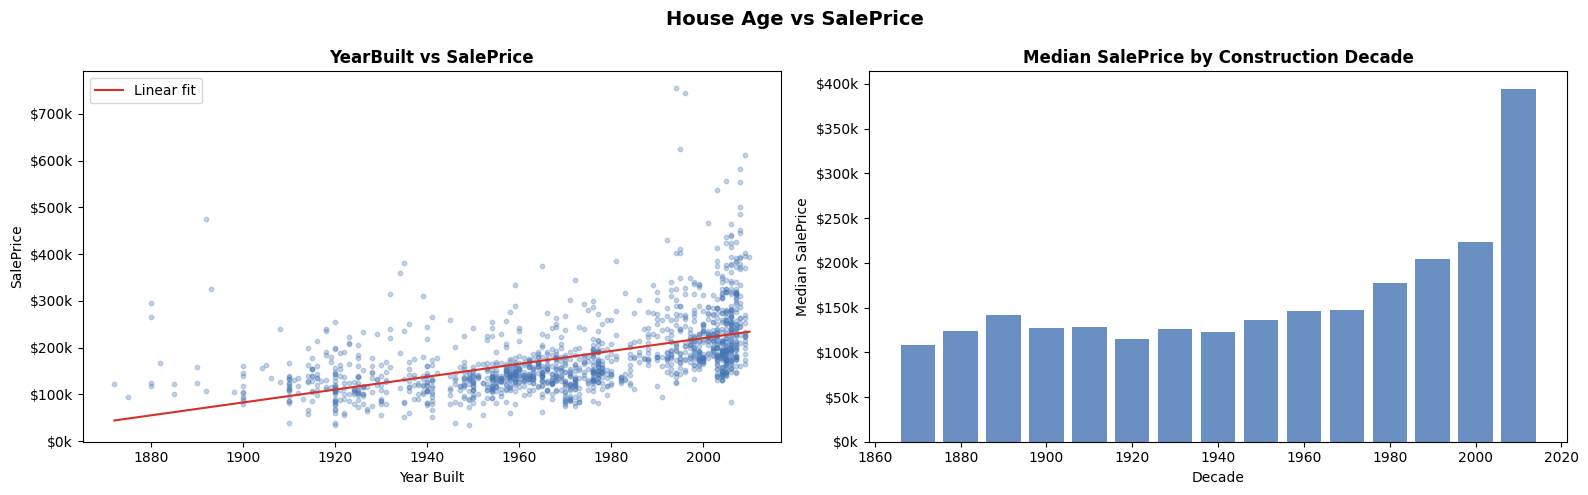

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# scatter YearBuilt vs SalePrice
axes[0].scatter(train['YearBuilt'], train['SalePrice'],
                alpha=0.3, s=10, color='#4575b4')

# Regression line
m, b = np.polyfit(train['YearBuilt'], train['SalePrice'], 1)
x_line = np.linspace(train['YearBuilt'].min(), train['YearBuilt'].max(), 100)
axes[0].plot(x_line, m * x_line + b,
             color='#d73027', linewidth=1.5, label='Linear fit')

axes[0].set_title('YearBuilt vs SalePrice', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year Built')
axes[0].set_ylabel('SalePrice')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

# Median SalePrice by decade
train['Decade'] = (train['YearBuilt'] // 10) * 10
decade_price = (train.groupby('Decade')['SalePrice']
                     .median()
                     .reset_index())

axes[1].bar(decade_price['Decade'], decade_price['SalePrice'],
            width=8, color='#4575b4', alpha=0.8)
axes[1].set_title('Median SalePrice by Construction Decade',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Median SalePrice')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('House Age vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

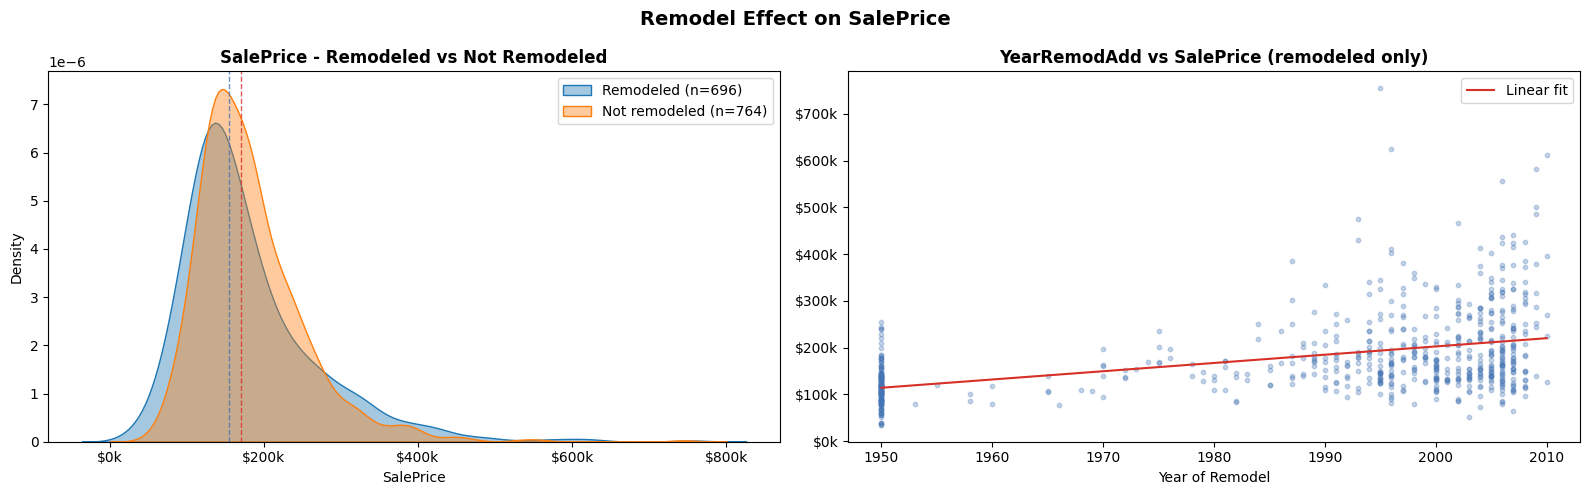

In [120]:
train['IsRemodeled'] = (train['YearRemodAdd'] != train['YearBuilt']).astype(int)

remodeled     = train[train['IsRemodeled'] == 1]['SalePrice']
not_remodeled = train[train['IsRemodeled'] == 0]['SalePrice']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE remodeled vs not
sns.kdeplot(remodeled,     ax=axes[0], fill=True, alpha=0.4,
            label=f'Remodeled (n={len(remodeled)})')
sns.kdeplot(not_remodeled, ax=axes[0], fill=True, alpha=0.4,
            label=f'Not remodeled (n={len(not_remodeled)})')
axes[0].axvline(remodeled.median(),     linestyle='--', linewidth=1,
                color='#4575b4', alpha=0.8)
axes[0].axvline(not_remodeled.median(), linestyle='--', linewidth=1,
                color='#d73027', alpha=0.8)
axes[0].set_title('SalePrice - Remodeled vs Not Remodeled',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('SalePrice')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

# Scatter YearRemodAdd vs SalePrice (remodeled only)
remodeled_df = train[train['IsRemodeled'] == 1]
axes[1].scatter(remodeled_df['YearRemodAdd'], remodeled_df['SalePrice'],
                alpha=0.3, s=10, color='#4575b4')

m, b = np.polyfit(remodeled_df['YearRemodAdd'],
                  remodeled_df['SalePrice'], 1)
x_line = np.linspace(remodeled_df['YearRemodAdd'].min(),
                     remodeled_df['YearRemodAdd'].max(), 100)
axes[1].plot(x_line, m * x_line + b,
             color='#d73027', linewidth=1.5, label='Linear fit')
axes[1].set_title('YearRemodAdd vs SalePrice (remodeled only)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year of Remodel')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].legend()

plt.suptitle('Remodel Effect on SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.2 Market Timing vs SalePrice

Real estate markets are sensitive to macroeconomic conditions and seasonal
patterns. This section examines whether the year and month of sale influence
`SalePrice` - a effect distinct from the intrinsic characteristics of the
property itself. The dataset covers 2006 to 2010, a particularly interesting
period that spans the peak and contraction of the US housing market.

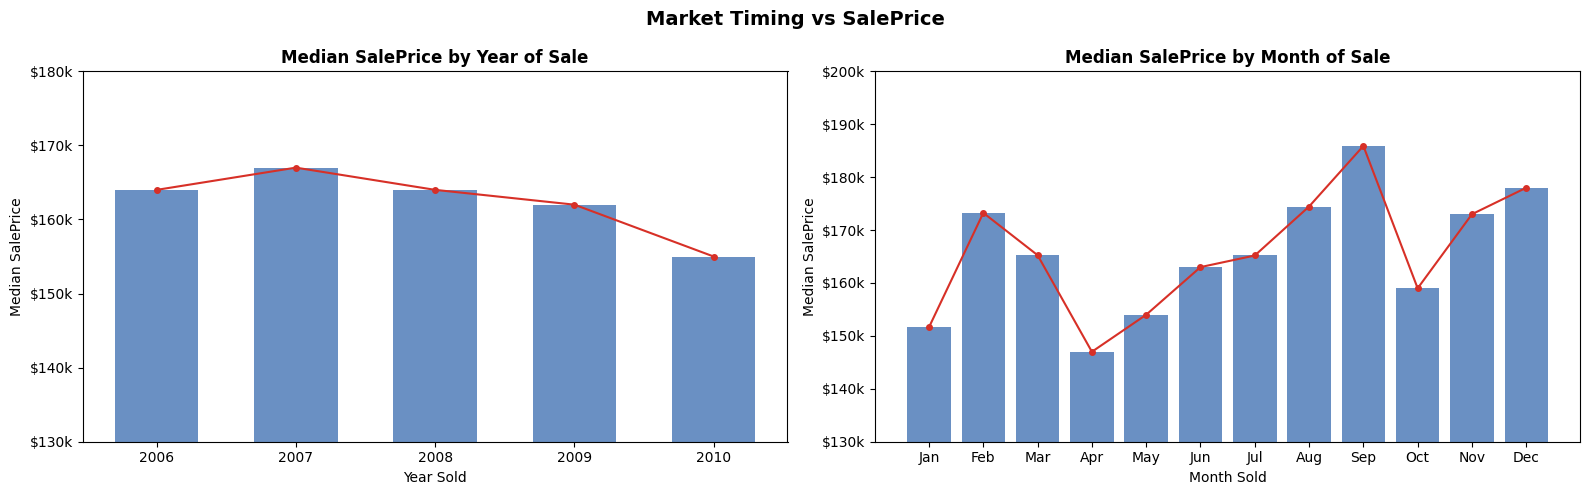

Median SalePrice by year:
  2006 - $163,995  (n=314)
  2007 - $167,000  (n=329)
  2008 - $164,000  (n=304)
  2009 - $162,000  (n=338)
  2010 - $155,000  (n=175)


In [117]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Median SalePrice by year of sale
year_price = (train.groupby('YrSold')['SalePrice']
                   .agg(['median', 'mean', 'count'])
                   .reset_index())

axes[0].bar(year_price['YrSold'], year_price['median'],
            color='#4575b4', alpha=0.8, width=0.6)
axes[0].plot(year_price['YrSold'], year_price['median'],
             color='#d73027', linewidth=1.5, marker='o', markersize=4)
axes[0].set_title('Median SalePrice by Year of Sale',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year Sold')
axes[0].set_ylabel('Median SalePrice')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_xticks(year_price['YrSold'])
axes[0].set_ylim(130_000, 180_000)

# Median SalePrice by month of sale
month_price = (train.groupby('MoSold')['SalePrice']
                    .agg(['median', 'count'])
                    .reset_index())
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

axes[1].bar(month_price['MoSold'], month_price['median'],
            color='#4575b4', alpha=0.8)
axes[1].plot(month_price['MoSold'], month_price['median'],
             color='#d73027', linewidth=1.5, marker='o', markersize=4)
axes[1].set_title('Median SalePrice by Month of Sale',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month Sold')
axes[1].set_ylabel('Median SalePrice')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_ylim(130_000, 200_000)

plt.suptitle('Market Timing vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Median SalePrice by year:")
for _, row in year_price.iterrows():
    print(f"  {int(row['YrSold'])} - ${row['median']:,.0f}  (n={int(row['count'])})")

### Key Takeaways - Temporal Analysis

**House age** shows a positive relationship with `SalePrice` - newer properties
command higher prices, with a visible acceleration post-1980. However the
relationship is noisy, confirming that age alone is insufficient and should be
combined with `OverallQual` to capture the quality-adjusted age effect.
An engineered feature `HouseAge = YrSold - YearBuilt` will replace `YearBuilt`
in `02_Preprocessing.ipynb`.

**Remodeling** produces a measurable price premium - remodeled properties show
a median price approximately $20k above non-remodeled ones. The effect strengthens
with recency of remodel, justifying an additional feature
`RemodAge = YrSold - YearRemodAdd` to capture how recent the renovation was.

**Year of sale** shows a modest declining trend over 2006–2010, consistent with
the US housing market contraction following the 2008 financial crisis. The effect
is small (~$10k median drop) relative to property-level drivers and does not
justify retaining `YrSold` as a standalone feature.

**Month of sale** shows a mild seasonal pattern with a spring/summer peak
(May–July) but the differences are modest (~$15k) and inconsistent across years.
`MoSold` will be excluded from the baseline model but flagged for re-evaluation
if residual analysis reveals systematic seasonal bias.

**Feature engineering decisions flowing into `02_Preprocessing.ipynb`:**

| Feature | Action | Rationale |
|---|---|---|
| `YearBuilt` | Replace with `HouseAge = YrSold - YearBuilt` | More interpretable, linear signal |
| `YearRemodAdd` | Replace with `RemodAge = YrSold - YearRemodAdd` | Captures recency of renovation |
| `GarageYrBlt` | Drop | Redundant with `HouseAge` (r = 0.83) |
| `YrSold` | Drop | Weak signal, risk of data leakage on future data |
| `MoSold` | Drop (baseline) | Inconsistent seasonal effect |
| `Decade` | Drop | Temporary EDA feature, not carried forward |

## 11. Conclusion - Exploratory Data Analysis

This exploratory analysis examined 1,460 observations across 79 features of the
Ames Housing dataset. Each section was designed to build on the previous one,
moving from data quality assessment to feature understanding to modeling decisions.

### What we found

**Missing values** are largely not missing. 16 of the 19 affected features encode
the physical absence of a characteristic - no pool, no garage, no basement - and
will be filled accordingly rather than imputed or dropped. Only 3 features
(`LotFrontage`, `GarageYrBlt`, `Electrical`) represent genuine data gaps.

**Categorical features** split into two groups. Quality features (`KitchenQual`,
`ExterQual`, `BsmtQual`, `GarageFinish`) show a strong, monotonic relationship
with price and will be ordinally encoded. Structural features (`BldgType`,
`MSZoning`, `HouseStyle`) show more heterogeneous patterns and will be one-hot
encoded. `SaleCondition` requires special treatment - partial sales correspond
to new constructions and will be isolated as a binary flag.

**The target variable** `SalePrice` is right-skewed (skewness ≈ 1.88), with a
mean approximately $15k above the median. A `log1p` transformation will be
applied before modeling.

**Six numerical features** show strong linear correlation with `SalePrice`
(r ≥ 0.6): `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64),
`GarageArea` (0.62), `TotalBsmtSF` (0.61), and `1stFlrSF` (0.61). Quality
consistently outperforms physical size as a price driver.

**Outliers** fall into two categories. Two observations with `GrLivArea > 4,000
sq ft` and price below $300k contradict the established linear trend and will
be removed. High-price properties above $400k are genuine luxury homes in premium
neighborhoods and will be retained.

**Multicollinearity** is concentrated in three clusters - garage features
(`GarageArea` <-> `GarageCars`, r = 0.88), surface features (`TotalBsmtSF` ↔
`1stFlrSF`, r = 0.82), and temporal features (`YearBuilt` <-> `GarageYrBlt`,
r = 0.83). One feature per redundant pair will be retained during feature
selection.

**Temporal patterns** confirm that construction year is a meaningful predictor,
with median prices accelerating sharply for homes built after 1980. The year of
sale captures a subtle market contraction between 2006 and 2010 consistent with
the US housing crisis. Monthly seasonality is present but modest (~$35k range).

---

### Decisions carried forward to preprocessing

| Decision | Rationale |
|----------|-----------|
| Fill semantic NaN with `'None'` or `0` | Absence of feature, not missing data |
| Impute `LotFrontage` by neighborhood median | Street configuration is location-dependent |
| Apply `log1p` to `SalePrice` | Right-skewed distribution |
| Remove 2 outliers (`GrLivArea` > 4k, price < $300k) | Contradict linear trend |
| Ordinal encode quality features | Monotonic order confirmed by EDA |
| One-hot encode structural features | No natural ordering |
| Create `is_new_construction` flag | Partial sales form a distinct price segment |
| Create `HouseAge` = `YrSold` − `YearBuilt` | More interpretable than raw year |
| Retain `GarageCars` over `GarageArea` | Less redundant, more interpretable |
| Retain `GrLivArea` over `TotalBsmtSF` / `1stFlrSF` | Most independent surface predictor |